# Binary routing classifier v2 — bake-off

Compare multiple classifiers on the **same TF-IDF feature space**.

**In scope**
- One shared `Pipeline(tfidf → dense → clf)`
- One `GridSearchCV` with a **list of param dicts** (one per classifier — params are not mixed across models)
- Holdout comparison vs **v1 tuned** only
- Confusion matrix **per model**; **one ROC figure** with all models
- Top-feature plots for **every** model
- Cross-version table: dummies + v0 + v1 + v2 winner

**Out of scope:** stacking, SVD, label-only baselines, Layer B, embeddings


## 1. Setup


In [76]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.base import clone
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


class ToDense(BaseEstimator, TransformerMixin):
    """Sparse → dense; class form so the pipeline pickles cleanly from notebooks."""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.toarray() if hasattr(X, "toarray") else X


In [77]:
def resolve_data_path(filename: str = "synthetic_topic_articles_v4.csv") -> Path:
    candidates = [
        Path.cwd() / "data" / filename,
        Path.cwd() / "../data" / filename,
        Path.cwd().parent / "data" / filename,
    ]
    for path in candidates:
        if path.resolve().exists():
            return path.resolve()
    raise FileNotFoundError(
        f"Could not find {filename}. Tried:\n" + "\n".join(str(p.resolve()) for p in candidates)
    )

DATA_PATH = resolve_data_path()
print("Loading:", DATA_PATH)


Loading: /Users/jianchenyang/Documents/projects/file_topic_routing/data/synthetic_topic_articles_v4.csv


## 2. Load, label, stratified split


In [79]:
df = pd.read_csv(DATA_PATH)
df["y"] = (df["routing_label"] == "target").astype(int)

X = df["article_text"]
y = df["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"train: {len(X_train)}  test: {len(X_test)}")
print("train pos rate:", round(y_train.mean(), 3), " test pos rate:", round(y_test.mean(), 3))


train: 160  test: 40
train pos rate: 0.35  test pos rate: 0.35


In [116]:
df["article_text"][0]

"Recent announcements around returns management reveal a market that is expanding but not yet standardized.\n\nWorkforce constraints are another concern. Companies need technical specialists as well as operational employees who understand how the new capability affects day-to-day decisions.\n\nExecutives are also paying attention to supplier concentration and contract flexibility. A technically successful deployment may still create long-term risk when switching costs are high or critical components come from a narrow group of vendors.\n\nSeveral organizations have adopted a pilot-first approach. They are limiting the initial scope, documenting operating assumptions, and expanding only after teams demonstrate that the new process can be supported at scale.\n\nAnalysts said the program's credibility will depend on transparent reporting and consistent performance after the initial launch period."

In [118]:
df["article_text"][2]

'A growing number of operators are reconsidering how they approach AI infrastructure, particularly as recovery time becomes a board-level concern.\n\nRegulatory requirements and data-governance expectations are influencing project design. Teams are building auditability and reporting into the program rather than treating compliance as a final review step.\n\n"Customers notice reliability and service quality long before they notice the underlying technology," said Maya Chen, a fictional market analyst.\n\nThe initiative includes phased deployment, new vendor contracts, staff training, and a revised measurement framework. Leaders said they will review recovery time monthly and adjust spending when early results differ from the original forecast.\n\nThe economics remain closely watched. Upfront investment can be significant, while benefits often emerge through a combination of lower operating expense, better capacity use, and improved customer experience.\n\nThe project also uses enterpri

## 3. Shared pipeline + per-classifier param grids

Approach **A**: one `Pipeline` for all models. `GridSearchCV(param_grid=[dict, dict, ...])` so each classifier’s hyperparams live in its own dict and are **not** constrained by other models.

`dense` is always on (n=200 — cheap) so LR / NB / SVM / trees / boosting share the same step layout.


In [81]:
pipe = Pipeline(
    [
        ("tfidf", TfidfVectorizer(sublinear_tf=True)),
        ("dense", ToDense()),
        ("clf", LogisticRegression()),  # placeholder; replaced per grid dict
    ]
)

# Shared TF-IDF choices (repeated inside each clf dict so each model can pick its own best)
TFIDF_NGRAM = [(1, 1), (1, 2)]
TFIDF_MIN_DF = [1, 2]
TFIDF_MAX_FEAT = [5000, 10000, None]


def tfidf_grid():
    return {
        "tfidf__ngram_range": TFIDF_NGRAM,
        "tfidf__min_df": TFIDF_MIN_DF,
        "tfidf__max_features": TFIDF_MAX_FEAT,
    }


# Calibrated LinearSVC so we get predict_proba for ROC
linear_svc = CalibratedClassifierCV(
    LinearSVC(class_weight="balanced", max_iter=5000, random_state=RANDOM_STATE),
    cv=3,
)

param_grid = [
    {
        "clf": [
            LogisticRegression(
                class_weight="balanced",
                max_iter=2000,
                solver="liblinear",
                random_state=RANDOM_STATE,
            )
        ],
        "clf__C": [0.1, 1.0, 10.0],
        **tfidf_grid(),
    },
    {
        "clf": [linear_svc],
        "clf__estimator__C": [0.1, 1.0, 10.0],
        **tfidf_grid(),
    },
    {
        "clf": [MultinomialNB()],
        "clf__alpha": [0.1, 0.5, 1.0],
        **tfidf_grid(),
    },
    {
        "clf": [
            RandomForestClassifier(
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )
        ],
        "clf__n_estimators": [200, 400],
        "clf__max_depth": [None, 20],
        "clf__min_samples_leaf": [1, 2],
        **tfidf_grid(),
    },
    {
        "clf": [
            XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=RANDOM_STATE,
                n_jobs=-1,
                verbosity=0,
            )
        ],
        "clf__n_estimators": [200, 400],
        "clf__max_depth": [3, 6],
        "clf__learning_rate": [0.05, 0.1],
        **tfidf_grid(),
    },
    {
        "clf": [
            LGBMClassifier(
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1,
                verbosity=-1,
            )
        ],
        "clf__n_estimators": [200, 400],
        "clf__num_leaves": [15, 31],
        "clf__learning_rate": [0.05, 0.1],
        **tfidf_grid(),
    },
    {
        "clf": [
            CatBoostClassifier(
                auto_class_weights="Balanced",
                random_seed=RANDOM_STATE,
                verbose=0,
                allow_writing_files=False,
            )
        ],
        "clf__iterations": [200, 400],
        "clf__depth": [4, 6],
        "clf__learning_rate": [0.05, 0.1],
        **tfidf_grid(),
    },
]

print("param_grid blocks:", len(param_grid))


param_grid blocks: 7


## 4. Fit GridSearchCV


In [83]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

search = GridSearchCV(
    pipe,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=1,
)

search.fit(X_train, y_train)
print("global best CV F1:", round(search.best_score_, 4))
print("global best params:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")


Fitting 5 folds for each of 492 candidates, totalling 2460 fits


/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.11/

global best CV F1: 0.6579
global best params:
  clf: MultinomialNB()
  clf__alpha: 0.1
  tfidf__max_features: 5000
  tfidf__min_df: 1
  tfidf__ngram_range: (1, 1)


## 5. Per-classifier CV leaderboard

Recover each model family’s best CV score from `cv_results_` (not only the global winner).


,family,cv_f1,cv_f1_std,params
0,MultinomialNB,0.657918,0.136396,"{'clf': MultinomialNB(), 'clf__alpha': 0.1, 't..."
1,LinearSVC (calibrated),0.656169,0.214419,"{'clf': CalibratedClassifierCV(cv=3, ..."
2,LogisticRegression,0.654977,0.177497,{'clf': LogisticRegression(class_weight='balan...
3,XGBoost,0.512096,0.132331,"{'clf': XGBClassifier(base_score=None, booster..."
4,CatBoost,0.496476,0.057315,{'clf': CatBoostClassifier(allow_writing_files...
5,LightGBM,0.469048,0.107960,{'clf': LGBMClassifier(class_weight='balanced'...
6,RandomForest,0.350387,0.093136,{'clf': RandomForestClassifier(class_weight='b...


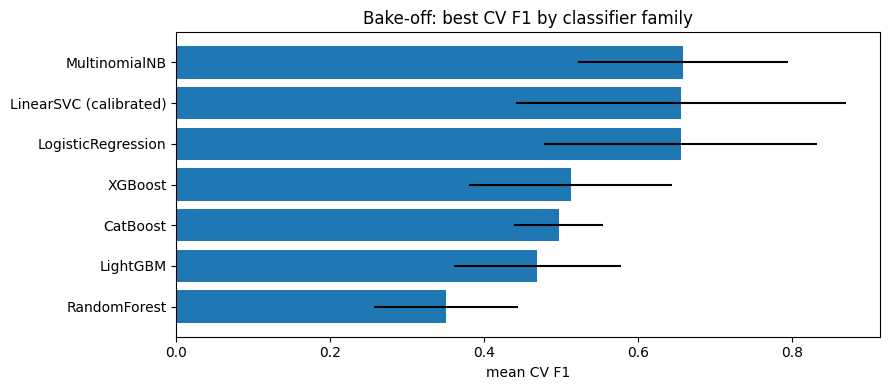

In [85]:
def clf_family(estimator) -> str:
    if isinstance(estimator, CalibratedClassifierCV):
        return "LinearSVC (calibrated)"
    name = type(estimator).__name__
    return {
        "LogisticRegression": "LogisticRegression",
        "MultinomialNB": "MultinomialNB",
        "RandomForestClassifier": "RandomForest",
        "XGBClassifier": "XGBoost",
        "LGBMClassifier": "LightGBM",
        "CatBoostClassifier": "CatBoost",
    }.get(name, name)


cv_df = pd.DataFrame(search.cv_results_)
cv_df["family"] = cv_df["param_clf"].apply(clf_family)

leaderboard = (
    cv_df.sort_values("mean_test_score", ascending=False)
    .groupby("family", as_index=False)
    .first()
    .loc[:, ["family", "mean_test_score", "std_test_score", "params"]]
    .sort_values("mean_test_score", ascending=False)
    .reset_index(drop=True)
)
leaderboard = leaderboard.rename(columns={"mean_test_score": "cv_f1", "std_test_score": "cv_f1_std"})
display(leaderboard[["family", "cv_f1", "cv_f1_std", "params"]])

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(leaderboard["family"][::-1], leaderboard["cv_f1"][::-1], xerr=leaderboard["cv_f1_std"][::-1])
ax.set_xlabel("mean CV F1")
ax.set_title("Bake-off: best CV F1 by classifier family")
plt.tight_layout()
plt.show()


## 6. Refit each family’s best config · holdout metrics vs v1

For each family, take its best param row, build that pipeline, fit on full train, score test @0.5.

Also reproduce **v1 tuned** (`C=10`, `ngram=(1,1)`, `min_df=1`, `max_features=5000`, sparse LR — densified here for a fair same-split compare).


/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,LinearSVC (calibrated),0.950,0.9286,0.9286,0.9286,0.9835,0.9708
1,LogisticRegression,0.850,0.7500,0.8571,0.8000,0.9451,0.9110
2,v1 tuned (reference),0.850,0.7500,0.8571,0.8000,0.9451,0.9110
3,MultinomialNB,0.850,0.7857,0.7857,0.7857,0.9533,0.9305
4,LightGBM,0.725,0.6000,0.6429,0.6207,0.6978,0.5973
5,CatBoost,0.750,0.7000,0.5000,0.5833,0.8214,0.7493
6,XGBoost,0.675,0.5385,0.5000,0.5185,0.7308,0.6181
7,RandomForest,0.700,0.6667,0.2857,0.4000,0.6360,0.5086


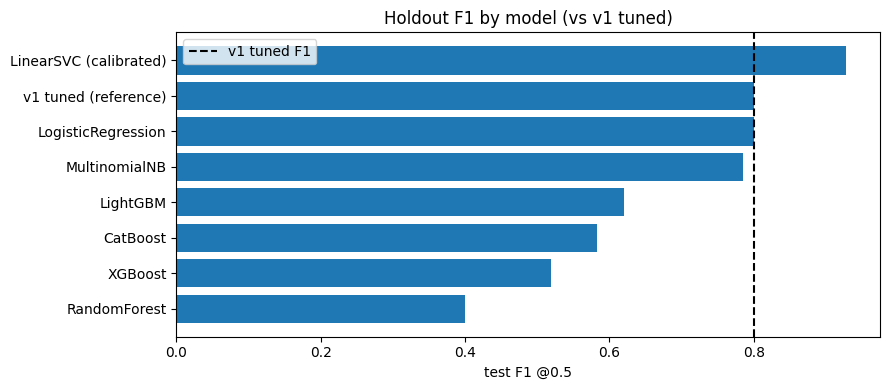

bake-off winner (excl. v1 reference): LinearSVC (calibrated)


In [87]:
def fit_from_params(params: dict):
    est = clone(pipe)
    # GridSearch stores estimator objects under "clf"
    est.set_params(**params)
    est.fit(X_train, y_train)
    return est


# best params per family
family_best_params = {}
for family, g in cv_df.groupby("family"):
    row = g.loc[g["mean_test_score"].idxmax()]
    family_best_params[family] = row["params"]

models = {}
for family, params in family_best_params.items():
    models[family] = fit_from_params(params)

# v1 tuned reference (same split)
v1_ref = Pipeline(
    [
        ("tfidf", TfidfVectorizer(sublinear_tf=True, ngram_range=(1, 1), min_df=1, max_features=5000)),
        ("dense", ToDense()),
        (
            "clf",
            LogisticRegression(
                C=10.0,
                class_weight="balanced",
                max_iter=2000,
                solver="liblinear",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
).fit(X_train, y_train)
models["v1 tuned (reference)"] = v1_ref


def holdout_row(name, model):
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return {
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, proba),
        "pr_auc": average_precision_score(y_test, proba),
        "pred": pred,
        "proba": proba,
    }


holdout_rows = [holdout_row(name, m) for name, m in models.items()]
holdout = pd.DataFrame(holdout_rows).drop(columns=["pred", "proba"])
holdout = holdout.sort_values("f1", ascending=False).reset_index(drop=True)
display(holdout.round(4))

# attach preds for later plots
holdout_detail = {r["model"]: r for r in holdout_rows}

fig, ax = plt.subplots(figsize=(9, 4))
plot_df = holdout.sort_values("f1")
ax.barh(plot_df["model"], plot_df["f1"])
ax.axvline(
    holdout_detail["v1 tuned (reference)"]["f1"],
    color="black",
    linestyle="--",
    label="v1 tuned F1",
)
ax.set_xlabel("test F1 @0.5")
ax.set_title("Holdout F1 by model (vs v1 tuned)")
ax.legend()
plt.tight_layout()
plt.show()

bakeoff = holdout[~holdout["model"].eq("v1 tuned (reference)")]
winner_name = bakeoff.loc[bakeoff["f1"].idxmax(), "model"]
print("bake-off winner (excl. v1 reference):", winner_name)


## 7. Confusion matrix per model · shared ROC


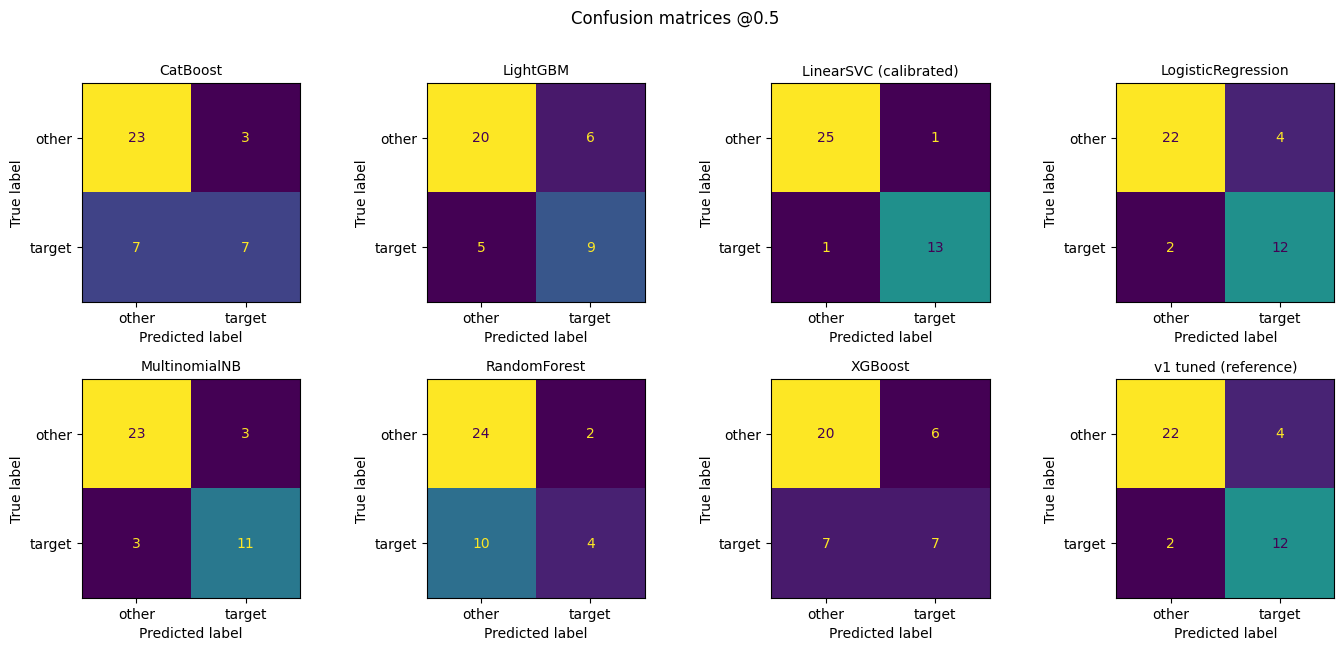

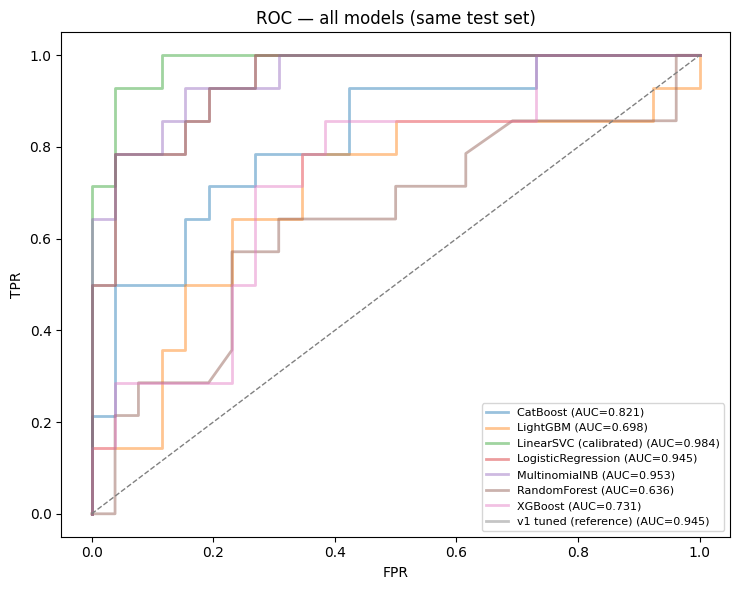

In [89]:
# Confusion matrices
names = list(holdout_detail.keys())
n = len(names)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.2 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, name in zip(axes, names):
    pred = holdout_detail[name]["pred"]
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, pred),
        display_labels=["other", "target"],
    ).plot(ax=ax, colorbar=False)
    ax.set_title(name, fontsize=10)

for ax in axes[len(names):]:
    ax.axis("off")

fig.suptitle("Confusion matrices @0.5", y=1.01)
plt.tight_layout()
plt.show()

# One ROC with all models (alpha helps when curves overlap)
ROC_ALPHA = 0.45
fig, ax = plt.subplots(figsize=(7.5, 6))
for name, d in holdout_detail.items():
    fpr, tpr, _ = roc_curve(y_test, d["proba"])
    ax.plot(
        fpr, tpr,
        alpha=ROC_ALPHA,
        linewidth=2,
        label=f"{name} (AUC={d['roc_auc']:.3f})",
    )
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
ax.set_xlabel("FPR")
ax.set_ylabel("TPR")
ax.set_title("ROC — all models (same test set)")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()


## 8. Top features for every model

Linear / NB: signed scores (positive → target, negative → other).

Tree / boosting: impurity importances are unsigned by default — we **sign** them using the train mean TF-IDF gap (`mean(x|target) − mean(x|other)`), so both sides appear like the linear panels.


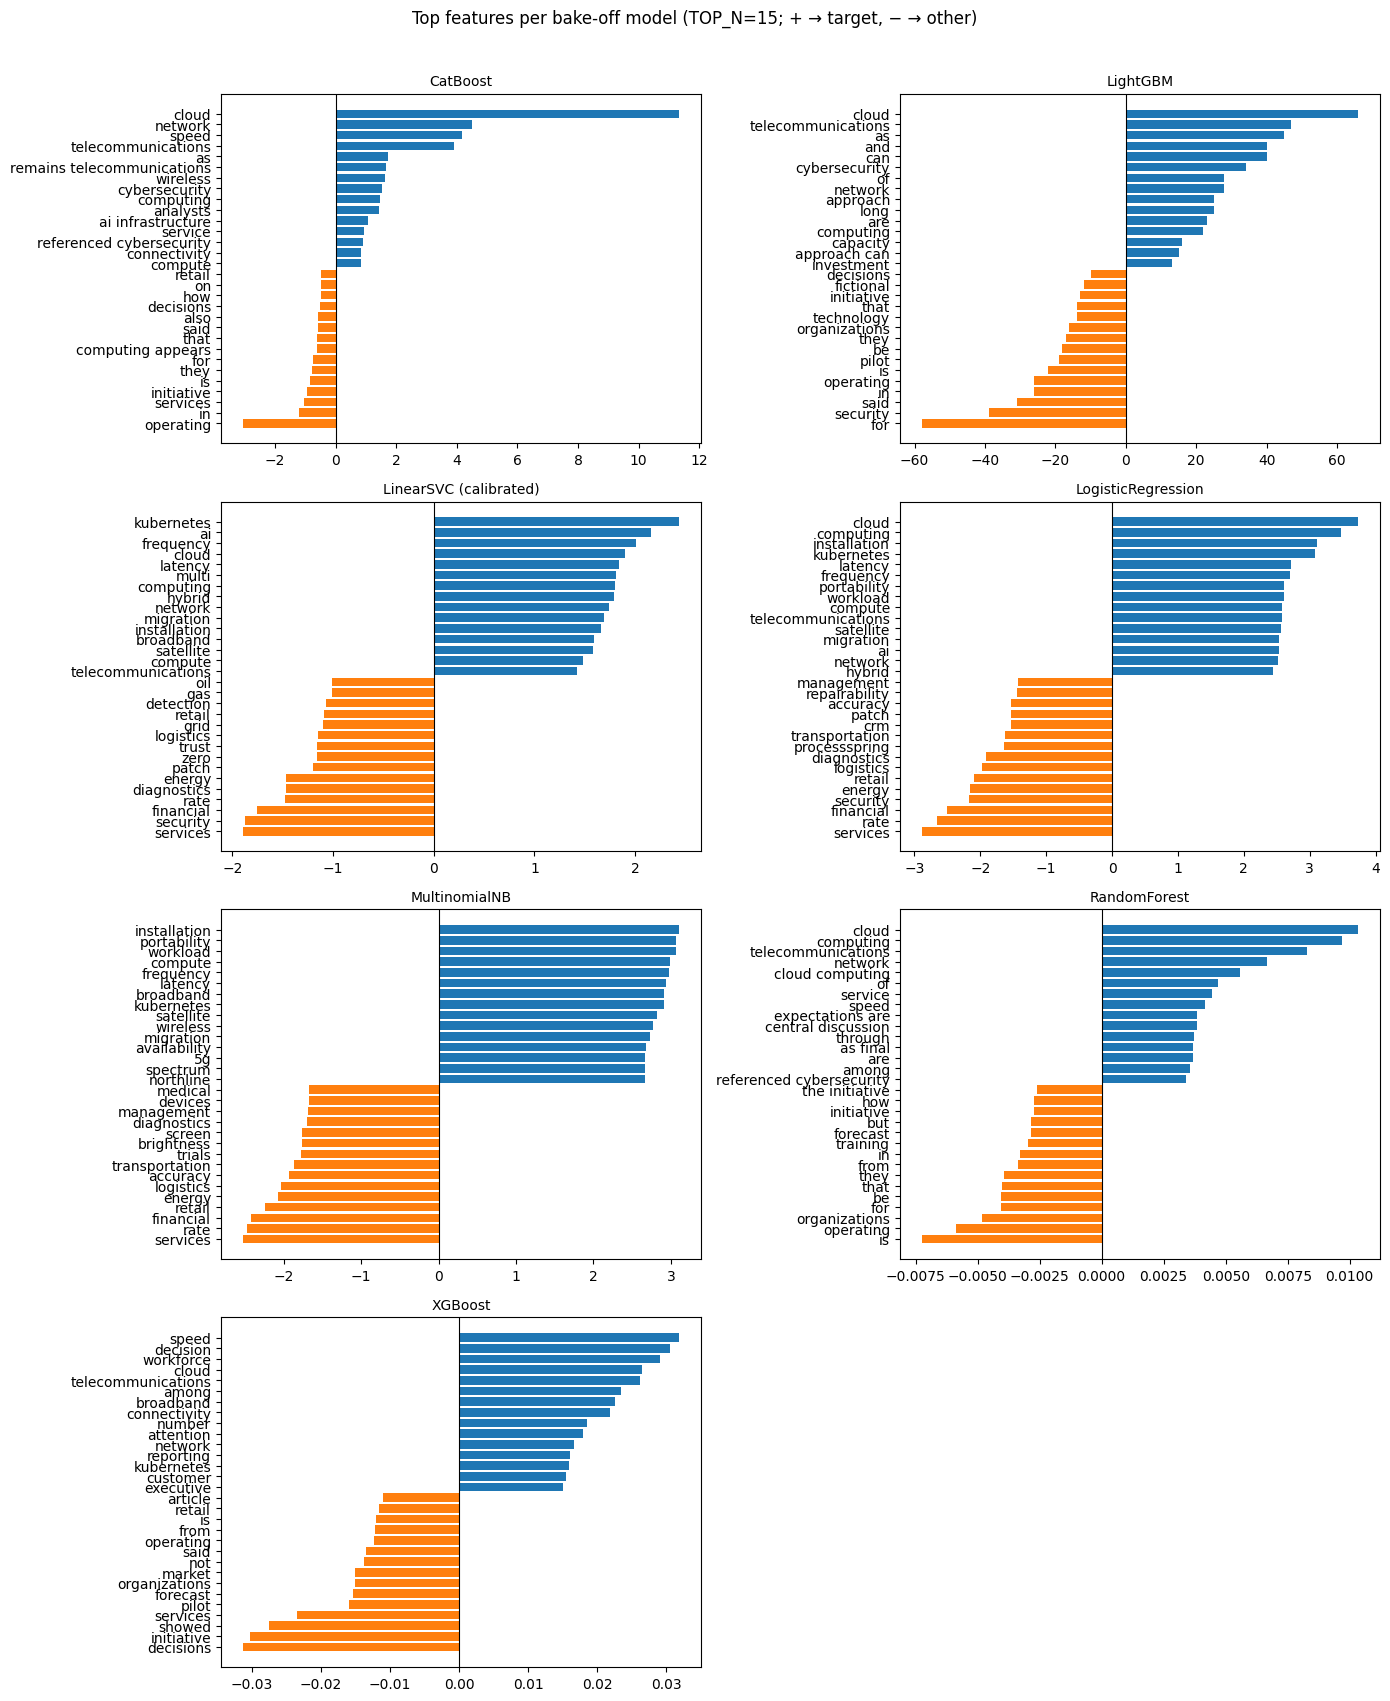

In [91]:
TOP_N = 15


def get_feature_names(model) -> np.ndarray:
    return np.array(model.named_steps["tfidf"].get_feature_names_out())


def _signed_tree_scores(model, X_ref, y_ref) -> np.ndarray:
    """Sign feature_importances_ by train association with target vs other."""
    clf = model.named_steps["clf"]
    tfidf = model.named_steps["tfidf"]
    imp = np.asarray(clf.feature_importances_, dtype=float).ravel()
    X = tfidf.transform(X_ref)
    if hasattr(X, "toarray"):
        X = X.toarray()
    y_arr = np.asarray(y_ref)
    pos = y_arr == 1
    # avoid empty class (shouldn't happen with stratified split)
    delta = X[pos].mean(axis=0) - X[~pos].mean(axis=0)
    sign = np.sign(delta)
    sign[sign == 0] = 1.0  # ties: keep positive so importance still shows
    return imp * sign


def top_scores_for_model(model):
    clf = model.named_steps["clf"]
    names = get_feature_names(model)

    if isinstance(clf, CalibratedClassifierCV):
        # average base estimator coefs across calibration folds when available
        coefs = []
        for est in getattr(clf, "calibrated_classifiers_", []):
            base = getattr(est, "estimator", None) or getattr(est, "base_estimator", None)
            if base is not None and hasattr(base, "coef_"):
                coefs.append(np.asarray(base.coef_).ravel())
        if not coefs and hasattr(clf, "estimator") and hasattr(clf.estimator, "coef_"):
            coefs.append(np.asarray(clf.estimator.coef_).ravel())
        if not coefs:
            return None, None
        score = np.mean(coefs, axis=0)
        return names, score

    if hasattr(clf, "coef_"):
        return names, clf.coef_.ravel()

    if isinstance(clf, MultinomialNB):
        score = clf.feature_log_prob_[1] - clf.feature_log_prob_[0]
        return names, score

    if hasattr(clf, "feature_importances_"):
        return names, _signed_tree_scores(model, X_train, y_train)

    return None, None


def plot_top_features(ax, title, names, scores, top_n=TOP_N):
    # show top positive (→ target) and top negative (→ other)
    pos_idx = np.argsort(scores)[-top_n:]
    neg_idx = np.argsort(scores)[:top_n]
    idx = np.concatenate([neg_idx, pos_idx])
    seen = set()
    ordered = []
    for i in idx:
        if i not in seen:
            seen.add(i)
            ordered.append(i)
    idx = np.array(ordered)
    idx = idx[np.argsort(scores[idx])]  # ascending for barh
    colors = np.where(scores[idx] >= 0, "C0", "C1")
    ax.barh(names[idx], scores[idx], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(title, fontsize=10)


plot_models = [(k, v) for k, v in models.items() if k != "v1 tuned (reference)"]
n = len(plot_models)
ncols = 2
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.2 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, (name, model) in zip(axes, plot_models):
    feat_names, scores = top_scores_for_model(model)
    if scores is None:
        ax.text(0.5, 0.5, f"No feature scores for\n{name}", ha="center", va="center")
        ax.axis("off")
        continue
    plot_top_features(ax, name, feat_names, scores)

for ax in axes[len(plot_models):]:
    ax.axis("off")

fig.suptitle(
    f"Top features per bake-off model (TOP_N={TOP_N}; + → target, − → other)",
    y=1.01,
)
plt.tight_layout()
plt.show()


## 9. Winner snapshot

Classification report + ROC for the bake-off winner (excludes v1 reference row).


Winner: LinearSVC (calibrated)
              precision    recall  f1-score   support

       other       0.96      0.96      0.96        26
      target       0.93      0.93      0.93        14

    accuracy                           0.95        40
   macro avg       0.95      0.95      0.95        40
weighted avg       0.95      0.95      0.95        40

vs v1 tuned F1: 0.8  | winner F1: 0.9286


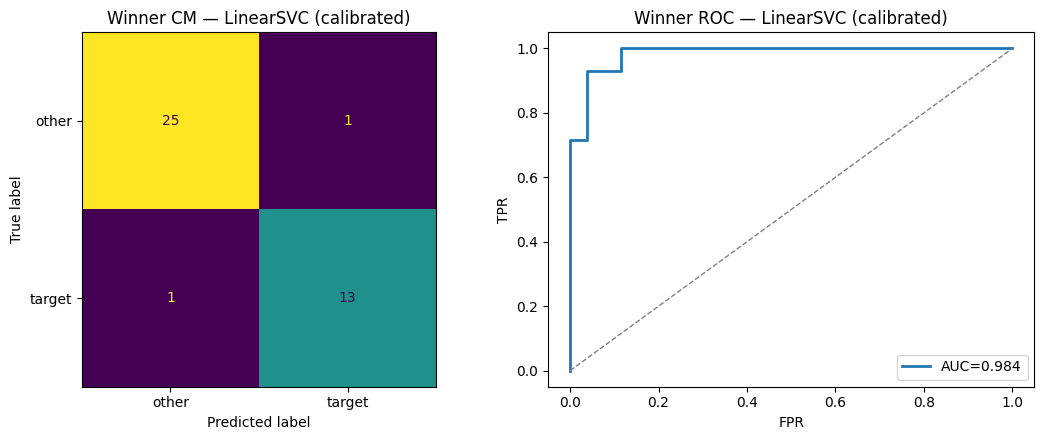

In [93]:
bakeoff = holdout[~holdout["model"].eq("v1 tuned (reference)")]
winner = bakeoff.loc[bakeoff["f1"].idxmax(), "model"]
print("Winner:", winner)
print(classification_report(
    y_test,
    holdout_detail[winner]["pred"],
    target_names=["other", "target"],
))
print(
    "vs v1 tuned F1:", round(holdout_detail["v1 tuned (reference)"]["f1"], 4),
    " | winner F1:", round(holdout_detail[winner]["f1"], 4),
)

# Winner ROC (+ confusion for a compact snapshot)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, holdout_detail[winner]["pred"]),
    display_labels=["other", "target"],
).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f"Winner CM — {winner}")

fpr, tpr, _ = roc_curve(y_test, holdout_detail[winner]["proba"])
axes[1].plot(fpr, tpr, linewidth=2, label=f"AUC={holdout_detail[winner]['roc_auc']:.3f}")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
axes[1].set_xlabel("FPR")
axes[1].set_ylabel("TPR")
axes[1].set_title(f"Winner ROC — {winner}")
axes[1].legend(loc="lower right")
plt.tight_layout()
plt.show()


## 10. Cross-version comparison — dummies + v0 + v1 + v2

Same holdout split. Rows:

| row | what |
|---|---|
| Always majority / Random w/ train rates / Coin flip 50/50 | label-only dummies |
| **v0** | fixed TF-IDF + LR (same defaults as `ml_binary_v0`) |
| **v1 tuned** | TF-IDF + LR as in this notebook's v1 reference |
| **v2 winner** | bake-off winner from above |

Metrics @ decision threshold 0.5.


,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
Always majority class,0.650,0.0000,0.0000,0.0000,0.5000,0.3500
Random w/ train rates,0.525,0.2727,0.2143,0.2400,0.4533,0.3334
Coin flip 50/50,0.450,0.3000,0.4286,0.3529,0.5000,0.3500
v0 (fixed TF-IDF+LR),0.650,0.5000,0.5714,0.5333,0.7720,0.7201
v1 tuned,0.850,0.7500,0.8571,0.8000,0.9451,0.9110
v2 winner (LinearSVC (calibrated)),0.950,0.9286,0.9286,0.9286,0.9835,0.9708


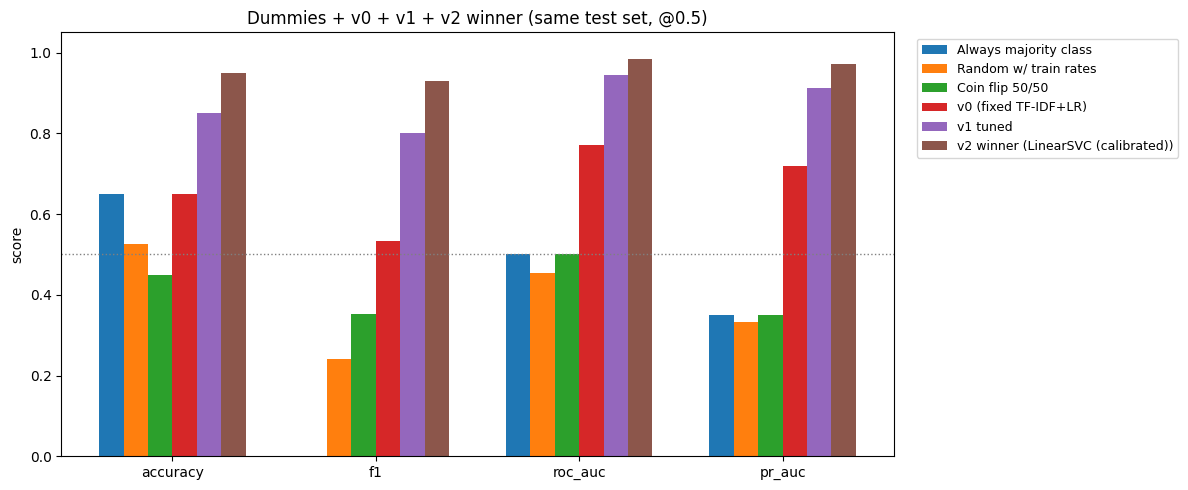

In [95]:
def eval_row(name, y_true, y_hat, y_score):
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_hat),
        "precision": precision_score(y_true, y_hat, zero_division=0),
        "recall": recall_score(y_true, y_hat, zero_division=0),
        "f1": f1_score(y_true, y_hat, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
        "pr_auc": average_precision_score(y_true, y_score),
    }


# v0: fixed pipeline matching ml_binary_v0
v0_model = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(
                ngram_range=(1, 2),
                min_df=2,
                max_features=10000,
                sublinear_tf=True,
            ),
        ),
        (
            "clf",
            LogisticRegression(
                C=1.0,
                class_weight="balanced",
                max_iter=2000,
                solver="liblinear",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
).fit(X_train, y_train)

version_rows = []

# 3 dummies
dummy_specs = [
    ("Always majority class", "most_frequent"),
    ("Random w/ train rates", "stratified"),
    ("Coin flip 50/50", "uniform"),
]
for name, strategy in dummy_specs:
    dummy = DummyClassifier(strategy=strategy, random_state=RANDOM_STATE)
    dummy.fit(X_train, y_train)
    y_hat = dummy.predict(X_test)
    y_score = dummy.predict_proba(X_test)[:, 1]
    version_rows.append(eval_row(name, y_test, y_hat, y_score))

# v0
v0_proba = v0_model.predict_proba(X_test)[:, 1]
v0_pred = (v0_proba >= 0.5).astype(int)
version_rows.append(eval_row("v0 (fixed TF-IDF+LR)", y_test, v0_pred, v0_proba))

# v1 tuned reference (already fitted earlier)
version_rows.append(
    eval_row(
        "v1 tuned",
        y_test,
        holdout_detail["v1 tuned (reference)"]["pred"],
        holdout_detail["v1 tuned (reference)"]["proba"],
    )
)

# v2 bake-off winner
version_rows.append(
    eval_row(
        f"v2 winner ({winner})",
        y_test,
        holdout_detail[winner]["pred"],
        holdout_detail[winner]["proba"],
    )
)

version_cmp = pd.DataFrame(version_rows).set_index("model")
display(version_cmp.round(4))

plot_metrics = ["accuracy", "f1", "roc_auc", "pr_auc"]
plot_df = version_cmp[plot_metrics]

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(plot_metrics))
width = 0.12
for i, (model_name, row) in enumerate(plot_df.iterrows()):
    ax.bar(x + i * width, row.values, width, label=model_name)
ax.set_xticks(x + width * (len(plot_df) - 1) / 2)
ax.set_xticklabels(plot_metrics)
ax.set_ylim(0, 1.05)
ax.set_ylabel("score")
ax.set_title("Dummies + v0 + v1 + v2 winner (same test set, @0.5)")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=9)
ax.axhline(0.5, color="gray", linestyle=":", linewidth=1)
plt.tight_layout()
plt.show()


## Save trained model

Saves the bake-off **winner** pipeline (not the full model zoo).

Artifact → `models/ml_binary_v2.joblib` (next to `data/`).


In [97]:
import joblib

MODELS_DIR = DATA_PATH.parent / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODELS_DIR / "ml_binary_v2.joblib"

joblib.dump(models[winner], MODEL_PATH)
print("saved:", MODEL_PATH.resolve())
print("reload example: loaded = joblib.load(MODEL_PATH)")


saved: /Users/jianchenyang/Documents/projects/file_topic_routing/data/models/ml_binary_v2.joblib
reload example: loaded = joblib.load(MODEL_PATH)


## Next

- Embeddings (frozen) + linear/MLP head
- Proper threshold / abstain tuning on train/val
- Real knowledge corpus
- Stacking only if later bake-offs show complementary errors
